In [38]:
import numpy as np
from torchvision.datasets import OxfordIIITPet
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.stats import multivariate_normal
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, ClassifierMixin

import models
import inference
import utils

In [2]:
dataset = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types=("segmentation", "category"),
    download=True
)

test_dataset = OxfordIIITPet(
    root="data",
    split="test",
    target_types=("segmentation", "category"),
    download=True
)

In [3]:
def preprocess(image, mask):
    small_image = image.copy()
    small_image.thumbnail((64,64))
    
    small_mask = mask.copy()
    small_mask.thumbnail((64,64))
    
    image = np.array(small_image)
    mask = np.array(small_mask)
    
    return image, mask

0


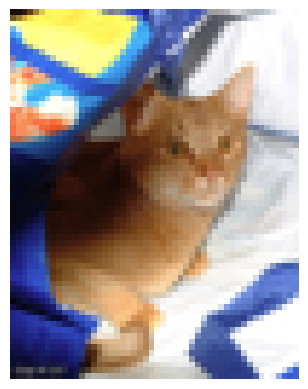

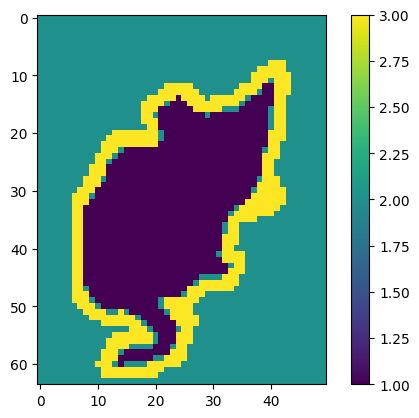

In [4]:
image, (mask, cat) = dataset[0]
image, mask = preprocess(image, mask)

print(cat)

plt.imshow(image)
plt.axis('off')
plt.show()

plt.figure()
plt.imshow(mask)
plt.colorbar()

In [6]:
colors = []
labels = []

for image, (mask, cat) in tqdm(dataset):
    if cat == 0:
        image, mask = preprocess(image, mask)
        mask = mask == 1
        fg = image[mask]
        colors.append(fg)
        labels.append(np.ones(len(fg)))
        bg = image[~mask]
        colors.append(bg)
        labels.append(np.zeros(len(bg)))

colors = np.concatenate(colors)
labels = np.concatenate(labels)

  0%|          | 0/3680 [00:00<?, ?it/s]

In [ ]:
class ColorsDensity(BaseEstimator, ClassifierMixin):
    def __init__(self, reg=1e-6):
        self.reg = reg
        
        self.models = [None, None]

    def fit(self, X, y):
        """
        X: (n_samples, 3)
        y: (n_samples,) binary labels
        """
        _, n_features = X.shape

        for c in range(2):
            X_c = X[y == c]

            mean = X_c.mean(axis=0)
            cov = np.cov(X_c, rowvar=False)
            cov += self.reg * np.eye(n_features)
            self.models[c] = multivariate_normal(mean=mean, cov=cov)

        return self

    def predict_proba(self, X):
        """
        Returns: (n_samples, n_classes)
        """
        probs = []
        
        for model in self.models:
            probs.append(model.pdf(X))

        probs = np.stack(probs)
        probs = probs / np.sum(probs, axis=0)
        
        return probs.T

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

In [59]:
model = LogisticRegression()
model.fit(colors, labels)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
model = ColorsDensity()
model.fit(colors, labels)

,reg,1e-06


In [47]:
def segmentation_graph_from_image(image : np.array, beta : float, sigma : float):
    graph = models.Graph(2)
    
    pairwise = np.exp(-np.array([[0, beta],
                                [beta, 0]]))
    
    H, W = image.shape[:2]
    
    def flat_idx(i, j):
        return i*W + j
    
    for i in tqdm(range(H)):
        for j in range(W):
            x = image[i, j]
            
            p = model.predict_proba(x.reshape(1, -1))[0]
            
            p = p / p.sum()
            k = flat_idx(i, j)
            graph.add_node(k, p)
            
            if j+1 < W:
                y = image[i, j+1]
                omega = np.exp(- np.linalg.norm(x - y)**2 / sigma ** 2)
                graph.add_edge(k, flat_idx(i, j+1), omega*pairwise)
            if i+1 < H:
                y = image[i+1, j]
                omega = np.exp(- np.linalg.norm(x - y)**2 / sigma ** 2)
                graph.add_edge(k, flat_idx(i+1, j), omega*pairwise)

    
    return graph

0


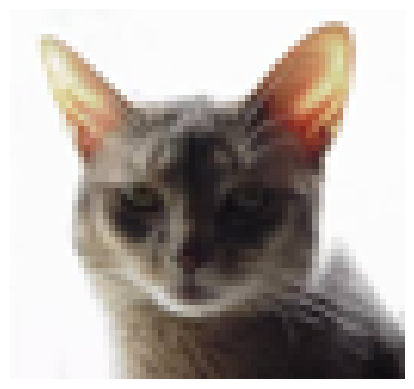

(60, 64, 3)

In [52]:
image, (mask, cat) = test_dataset[4]
image, mask = preprocess(image, mask)

print(cat)

plt.imshow(image)
plt.axis('off')
plt.show()
image.shape

In [53]:
graph = segmentation_graph_from_image(image, 1, 1)

  0%|          | 0/60 [00:00<?, ?it/s]

In [56]:
max_iter = 20
marginals = inference.loopy_bp(graph, max_iter)

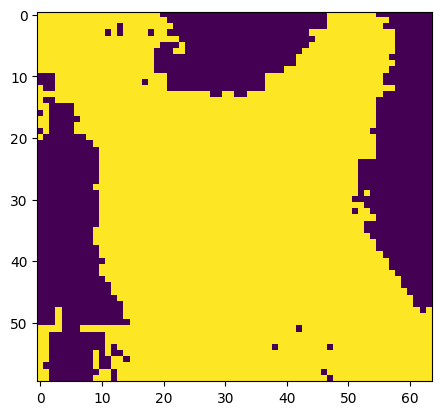

In [57]:
im = utils.image_from_marginals(image, marginals)
plt.imshow(im)